In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import re
import ast

In [ ]:
models = ['extended_double', 'extended_doublemlp', 'extended_doublemlp_loss', 'extendedBase', 'original']

In [ ]:
data = pd.read_pickle('./curves_all_models.pkl')

100%|██████████| 5/5 [00:26<00:00,  5.33s/it]


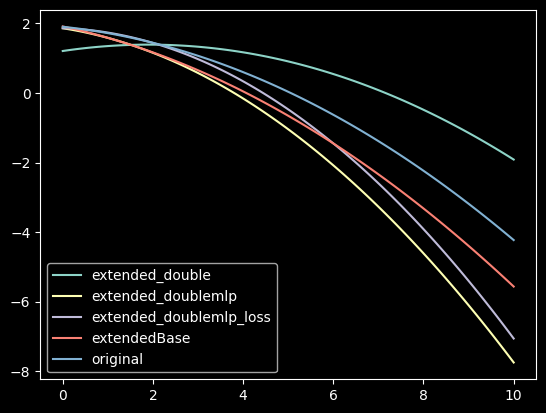

In [3]:
for m in tqdm(models):
    weights = torch.load(f'../train_notebooks/weights/{m}/weights.pt', map_location='cpu', weights_only=False)

    alpha = weights['model_state_dict']['alpha'].cpu().numpy()
    beta = weights['model_state_dict']['beta'].cpu().numpy()
    gamma = weights['model_state_dict']['gamma'].cpu().numpy()

    x = np.linspace(0, 10, 100)
    y = x * alpha + x**2 * beta + gamma

    plt.plot(x,y, label = m)

plt.legend()

In [4]:
# def interpolate_array(arr):
#     arr_float = arr.astype(float)
#     valid = ~np.isnan(arr_float)
#     indices = np.arange(len(arr_float))
#     arr_float[np.isnan(arr_float)] = np.interp(indices[np.isnan(arr_float)], indices[valid], arr_float[valid])
#     return arr_float
#
#
# dataframe_dict = {}
#
# for m in tqdm(models):
#     curve_df = pd.read_csv(f'../optimized/predict_notebooks/curves/{m}_predictions_for_curves.csv')
#     curve_df['score'] = curve_df['score'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
#     curve_df['prob'] = curve_df['prob'].apply(lambda x: np.array(ast.literal_eval(re.sub(r'np\.float64\(([^)]+)\)', r'\1', x).replace('nan', 'None')))).apply(interpolate_array)
#     dataframe_dict[m] = curve_df

In [5]:
# dataframe_dict[models[0]]

In [6]:
# pd.to_pickle(dataframe_dict, './curves_all_models.pkl')

In [7]:
df_full = pd.read_parquet('../sorted_data.parquet')

In [8]:
df_full['user_id'].value_counts()

user_id
451      3438
5812     3222
596      3202
12251    3135
5212     3115
         ... 
11339    1000
10602    1000
9716     1000
9733     1000
10898    1000
Name: count, Length: 13209, dtype: int64

In [9]:
data = pd.read_pickle('./curves_all_models.pkl')

In [10]:
user = 10

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def show_for_user(data, user_id, show=None, curve_id='score'):
    times = np.linspace(1654041600, 1661990376, 500)

    # create 2 subplots (one per item)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    item_ids = None  # we’ll capture them once

    for key, item in tqdm(data.items()):
        if show is None or key in show:
            user_item = item[item['user'] == user_id]

            if len(user_item) < 2:
                continue

            # store item ids once
            if item_ids is None:
                item_ids = [
                    user_item["item"].iloc[0],
                    user_item["item"].iloc[1],
                ]

            # plot first item
            axes[0].plot(
                times,
                user_item[curve_id].iloc[0],
                label=f'{key}_item_{item_ids[0]}',
                linewidth=2
            )

            # plot second item
            axes[1].plot(
                times,
                user_item[curve_id].iloc[1],
                label=f'{key}_item_{item_ids[1]}',
                linewidth=2
            )

    # --- vertical lines (lighter + behind) ---
    if item_ids is not None:
        for i, item_id in enumerate(item_ids):
            ts_values = df_full[
                (df_full['user_id'] == user_id) &
                (df_full['track_id'] == item_id)
            ]['ts'].to_numpy()

            for x in ts_values:
                axes[i].axvline(
                    x,
                    color='gray',
                    linestyle='--',
                    linewidth=1,
                    alpha=0.3,   # 👈 makes them less dominant
                    zorder=0     # 👈 pushes behind main lines
                )

    # legends and layout
    axes[0].legend()
    axes[1].legend()

    axes[0].set_title(f'User {user_id} - Item {item_ids[0]}' if item_ids else "")
    axes[1].set_title(f'User {user_id} - Item {item_ids[1]}' if item_ids else "")

    plt.tight_layout()
    plt.show()

100%|██████████| 5/5 [00:00<?, ?it/s]


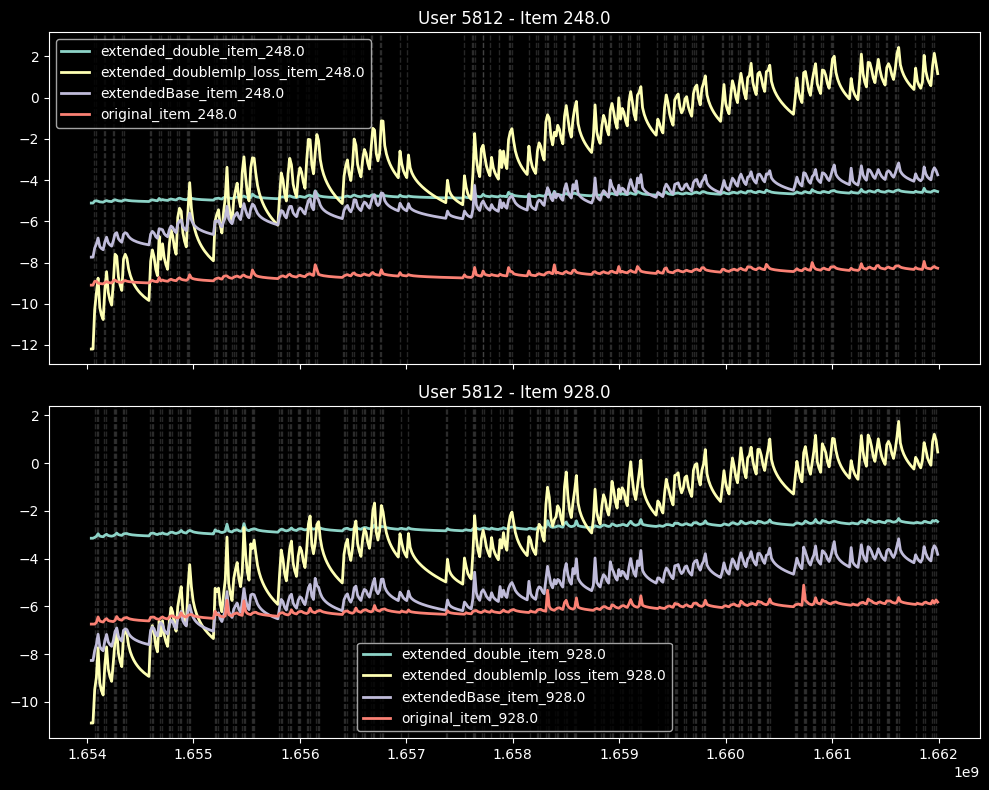

In [12]:
show_list = [
    'original',
    'extendedBase',
    'extended_double',
    # 'extended_doublemlp',
    'extended_doublemlp_loss',
]

show_for_user(data, 5812, show_list, 'score')

100%|██████████| 5/5 [00:00<00:00, 2478.61it/s]


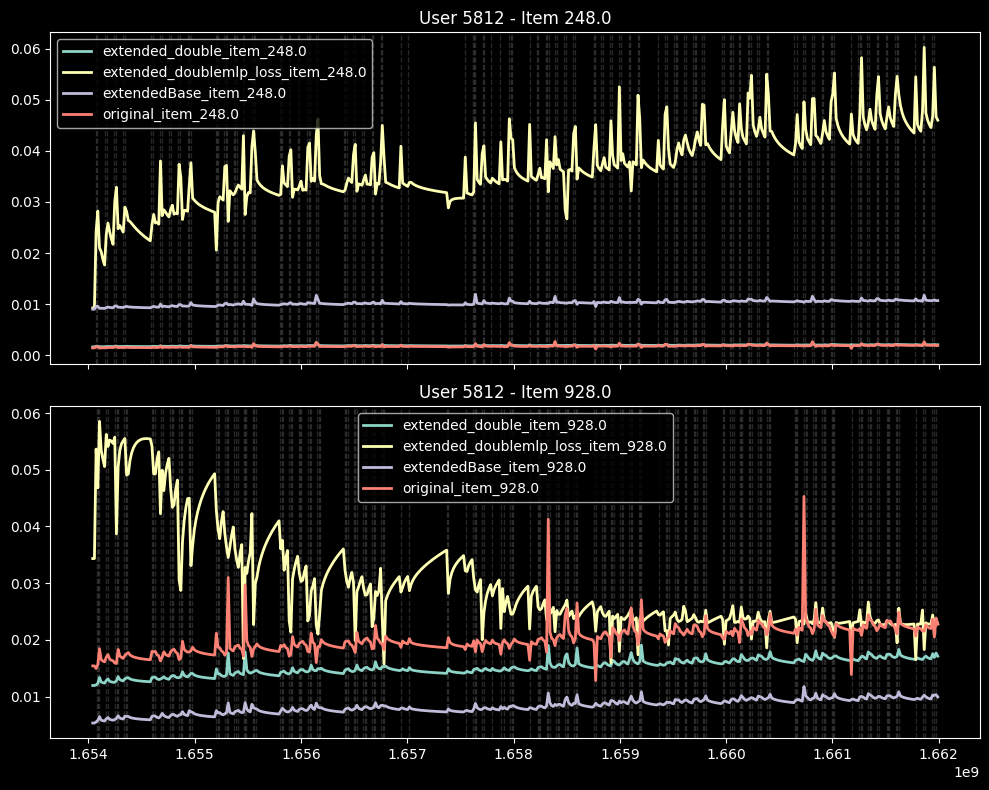

In [13]:
show_for_user(data, 5812, show_list, 'prob')

In [14]:
df_full[(df_full['user_id'] == 451) & (df_full['track_id']==109)]['ts'].to_numpy()

array([1654042679, 1654127986, 1654215475, 1654311781, 1654397383,
       1654479132, 1654523491, 1654561490, 1654661083, 1654733924,
       1654819905, 1654908615, 1654955887, 1655023982, 1655080497,
       1655168080, 1655251835, 1655338913, 1655426409, 1655548079,
       1655614293, 1655644440, 1655683856, 1655771396, 1655858412,
       1655955383, 1656029999, 1656128030, 1656217865, 1656290497,
       1656382060, 1656469193, 1656553257, 1656589125, 1656643382,
       1656736456, 1656817101, 1656895646, 1656982593, 1657068762,
       1657154241, 1657241937, 1657442722, 1657505932, 1657586651,
       1657675257, 1657790364, 1657845974, 1657951635, 1658044389,
       1658105860, 1658191745, 1658281566, 1658365318, 1658451502,
       1658559852, 1658579133, 1658629816, 1658713409, 1658797944,
       1658887279, 1658970378, 1659057019, 1659147707, 1659315754,
       1659489270, 1659574882, 1659661854, 1659753195, 1659840656,
       1659922990, 1660014028, 1660106868, 1660192798, 1660270